In [1]:
import sys
import os

os.environ["NUMBA_CACHE_DIR"] = "/tmp"   # stop numba filling ~/.cache

import gc
gc.collect()

# Check available memory before running
import psutil
mem = psutil.virtual_memory()
print(f"Available RAM: {mem.available/1e9:.1f} GB / {mem.total/1e9:.1f} GB total")

# Add the project root directory to Python's import path
project_root = os.path.abspath("../../../")
sys.path.append(project_root)

import OptiCommPy
print("Using:", OptiCommPy.__file__)

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe, ssfmDBP
from optic.dsp.carrierRecovery import cpr,fourthPowerFOE
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery
from optic.models.channels import nlinPhaseRot

import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time
#from numpy.fft import fftfreq, fft, ifft

Available RAM: 5.1 GB / 8.2 GB total
Using: None


In [2]:
# Run this ALONE in a cell before anything else to estimate memory
import numpy as np

nBits = 200000
M = 256
SpS = 16
SpSout = 2

nSymbols = int(nBits // np.log2(M))
sigLen_full = nSymbols * SpS        # full rate signal length
sigLen_dec  = nSymbols * SpSout     # decimated signal length

# complex128 = 16 bytes per sample
mem_full_MB  = sigLen_full * 16 / 1e6
mem_dec_MB   = sigLen_dec  * 16 / 1e6
mem_eq_MB    = 75 * sigLen_dec * 16 / 1e6   # equalizer tap matrix

print(f"nSymbols      : {nSymbols}")
print(f"Full-rate len : {sigLen_full} samples → {mem_full_MB:.1f} MB")
print(f"Decimated len : {sigLen_dec}  samples → {mem_dec_MB:.1f} MB")
print(f"EQ tap matrix : ~{mem_eq_MB:.1f} MB")
print(f"Rough total   : ~{(mem_full_MB*4 + mem_eq_MB):.1f} MB")

nSymbols      : 25000
Full-rate len : 400000 samples → 6.4 MB
Decimated len : 50000  samples → 0.8 MB
EQ tap matrix : ~60.0 MB
Rough total   : ~85.6 MB


In [3]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [4]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [5]:
def select_cpr_mode(paramCPR_, CPR_Mode, Ts, M):
    paramCPR = paramCPR_
    paramCPR.Ts = Ts
    paramCPR.M  = M
    paramCPR.returnPhases = True

    mode = CPR_Mode.lower()

    # =======================================================
    # BPS CPR (block phase search)
    # =======================================================
    if mode == "bps":
        paramCPR.alg = "bps"

        if M == 16:
            paramCPR.N = 25
            paramCPR.B = 64

        elif M == 64:
            paramCPR.N = 101
            paramCPR.B = 2048

        elif M == 256:
            paramCPR.N = 512
            paramCPR.B = 64

    # =======================================================
    # DDPLL CPR (decision-directed phase-locked loop)
    # =======================================================
    elif mode == "ddpll":
        paramCPR.alg = "ddpll"

        if M == 16:
            paramCPR.tau1 = 1/(2*np.pi*50e3)
            paramCPR.tau2 = 1/(2*np.pi*50e3)
            paramCPR.Kv   = 0.1

        elif M == 64:
            paramCPR.tau1 = 1/(2*np.pi*200e3)
            paramCPR.tau2 = 1/(2*np.pi*200e3)
            paramCPR.Kv   = 0.12

        elif M == 256:
            
            paramCPR.tau1 = 1/(2*np.pi * 200e3)   # loop bandwidth ~200 kHz
            paramCPR.tau2 = 1/(2*np.pi * 200e3)
            paramCPR.Kv   = 0.02                   # very gentle for 256-QAM
            
    else:
        raise ValueError("CPR_Mode must be 'bps', 'ddpll', 'pcpe', or 'pcpe_bps'")

    return paramCPR

In [6]:
def select_equalizer_mode(M, Data_Aided, paramEq_):
    paramEq = paramEq_

    # ==========================================================
    # DATA-AIDED MODE
    # ==========================================================
    if Data_Aided:

        if M == 16:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [5e-3, 5e-4]
            paramEq.numIter = 3
            paramEq.nTaps = 35

        elif M == 64:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [8e-4, 3e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 85   # upgraded

        elif M == 256:
            paramEq.alg = ['da-rde']
            paramEq.mu  = [ 8e-4]
            paramEq.numIter = 10
            paramEq.nTaps = 51   # absolutely required

    # ==========================================================
    # BLIND MODE (CMA → RDE)
    # ==========================================================
    else:
        if M == 16:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [3e-3, 8e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 35

        elif M == 64:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [1e-3, 6e-4]
            paramEq.numIter = 7
            paramEq.nTaps = 85   # critical for convergence

        elif M == 256:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [5e-4, 2e-4]
            paramEq.numIter = 10
            paramEq.nTaps = 200

    return paramEq

In [7]:
def perf_calc(symbTx, y_CPR_1, d_, M, paramSymb):
    """Performance Metric Exploration for Single Polarization"""
    d = d_
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    
    # Remove phase ambiguity for all M (optional: for QAM)
    if M in [4, 16, 32, 64, 128]:
        d = symbTx  # or processed reference symbols

    # Compute metrics
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

    return BER[0], SER[0], SNR[0], EVM[0], Qfactor

In [8]:
# ----------------------------------------------
# Simulation of the Optical System (parametric version)
# -----------------------------------------------
from copy import deepcopy
def simulate_optical_system_with_plots(
    symbTx,
    no_symbols_sent,
    M,
    PA_enable=True,
    Data_Aided=True,
    SpS=16,
    SpSout=2,
    Fs=None,
    mzmScale=0.8,
    Vpi=2,
    BLPF_enable=True,
    PA_BO_dB=3,
    PA_p=2.0,
    PA_f3dB=18.5e9,
    P_launch_dBm=0,
    Rs = 32e9,                
    rollOff = 0.01,           
    nFilterTaps = 1024,       
    laserLinewidth = 100e3, 
    FO  = -128e6,
    CPR_Mode = "bps",
    pulse_type="rrc",
    ch_Ltotal_km=80,
    ch_Lspan_km=80,
    ch_alpha_dB_per_km=0.2,
    ch_D_ps_nm_km=16,
    ch_gamma=1.3,
    ch_Fc=193.1e12,
    ch_hz_km=0.5,
    ch_prgsBar=True,
    ch_amp="edfa",
    ch_NF_dB=4.5,
    lo_P_dBm=2,
    lo_RIN_var=0,
    lo_freq_shift_base_hz=0,
    pn_tx_seed=123,
    lo_rx_seed=789,
    pd_seed=1011,
    pd_ideal=True,
    edc_Fs=None,
    pa_order=3,
    useDBP=False,
    paramDBP=None, 
    ):                

    
    # (derived) params
    if Fs is None:
        Fs = Rs * SpS
    # 3) UpSampling and FIR Parameters
    paramPulse = parameters()
    paramPulse.pulseType = pulse_type
    paramPulse.nFilterTaps = nFilterTaps
    paramPulse.rollOff = rollOff
    paramPulse.SpS = SpS

    # 4) IQM Parameters
    paramIQM = parameters()
    paramIQM.Vpi = Vpi
    paramIQM.VbI = -Vpi
    paramIQM.VbQ = -Vpi
    paramIQM.Vphi = Vpi/2

    # 5) Optical Carrier / LO field (Ein)
    sigTx_length = no_symbols_sent * SpS
    if laserLinewidth and laserLinewidth > 0:
        phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=pn_tx_seed)
        sigLO = np.exp(1j * phi_pn)
    else:
        sigLO = np.ones_like(sigTx_length, dtype=complex)


    # -----------------------------------------------
    # Channel Parameters
    #------------------------------------------------

    # 1) Optical Channel Parameters
    paramCh = parameters()
    paramCh.Ltotal = ch_Ltotal_km
    paramCh.Lspan = ch_Lspan_km
    paramCh.alpha = ch_alpha_dB_per_km
    paramCh.D = ch_D_ps_nm_km
    paramCh.gamma = ch_gamma
    paramCh.Fc = ch_Fc
    paramCh.hz = ch_hz_km
    paramCh.prgsBar = ch_prgsBar
    paramCh.Fs = Fs
    paramCh.amp = ch_amp
    paramCh.NF = ch_NF_dB
    #paramCh.seed = 456

    # ── Separate DBP parameter object (coarser steps, no adaptive step-size) ──
    paramDBP = deepcopy(paramCh)
    #paramDBP.nlprMethod = False   # fixed step size for DBP
    #paramDBP.hz         = 0.5      # coarser than forward: 10 km vs 0.5 km
    #paramDBP.prgsBar    = False
    #paramDBP.amp = None 
    # NF / amp / seed are irrelevant for DBP but harmless to carry over

    # -----------------------------------------------
    # Receiver Parameters
    #------------------------------------------------

    # 1) local oscillator (LO) parameters:

    paramLO = parameters()
    paramLO.P = lo_P_dBm
    paramLO.lw = laserLinewidth
    paramLO.RIN_var = lo_RIN_var
    paramLO.Fs = Fs
    paramLO.seed = lo_rx_seed
    paramLO.freqShift = lo_freq_shift_base_hz + FO

    # 2) Front-End Parameters and photodiode paramters

    # Frontend parameters
    paramFE = parameters()
    paramFE.Fs = Fs

    # Photodiodes parameters
    paramPD = parameters()
    paramPD.B = Rs
    paramPD.Fs = Fs
    paramPD.ideal = pd_ideal
    paramPD.seed = pd_seed

    # 3) Pulseshaping in the reciever using rrc filter
    paramRxPulse = parameters()
    paramRxPulse.SpS = SpS
    paramRxPulse.nFilterTaps = nFilterTaps
    paramRxPulse.rollOff = rollOff
    paramRxPulse.pulseType = pulse_type

    # 4) Decimation Parameters
    paramDec = parameters()
    paramDec.SpSin  = SpS
    paramDec.SpSout = SpSout

    # 5) Chromatic Dispersion Parameters
    paramEDC = parameters()
    paramEDC.L = paramCh.Ltotal
    paramEDC.D = paramCh.D
    paramEDC.Fc = paramCh.Fc
    paramEDC.Rs = Rs
    paramEDC.Fs = 2 * Rs if edc_Fs is None else edc_Fs

    # 6) Adaptive Equalization Parameters
    paramEq = parameters()
    paramEq.nTaps = 35
    paramEq.SpS = paramDec.SpSout
    paramEq.numIter = 2
    paramEq.storeCoeff = False
    paramEq.M = M
    paramEq.shapingFactor = 0
    paramEq.constType = "qam"
    paramEq.prgsBar = False

    # 7) Data-Aided or Blind Reciever Equalization
    # Can be set here or not
    #Data_Aided = True

    # 8) Carrier and Phase recovery parameters using bps
    paramCPR = parameters()
    paramCPR.alg = 'bps'
    paramCPR.M   = M
    paramCPR.constType ="qam"
    paramCPR.shapingFactor = 0
    paramCPR.N   = 25
    paramCPR.B   = 64
    paramCPR.returnPhases = True
    paramCPR.Ts = 1/Rs




    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # plotting eye diagrams of sigTx
    discard = 50*SpS  # number of samples to discard at the beginning and end of the signal for eye diagram
    #eyediagram(sigTx.real[discard:-discard], sigTx.real.size-2*discard, SpS, plotlabel='signal at Tx REAL', ptype='fancy')
    #eyediagram(sigTx.imag[discard:-discard], sigTx.imag.size-2*discard, SpS, plotlabel='signal at Tx IMAGNIARY', ptype='fancy')
    #print(sigTx.real[discard:-discard])
    #print(sigTx.imag.size-2*discard)

    # ===== RF PSD plot =====
    #fig, ax = plt.subplots(figsize=(16, 3))

    #ax.set_xlim(-3*Rs, 3*Rs)
    #ax.set_ylim(-250, -80)
    #ax.psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided',
    #   label='RF signal spectrum')
    #ax.legend(loc='upper left')

    #plt.tight_layout()
    #plt.show()

    

    # 3) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 4) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable=BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=pa_order,
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 5) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 6) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)
    print("TX power:", np.mean(np.abs(sigTxo)**2))

    # ===== Optical PSD plot =====
    #fig, ax = plt.subplots(figsize=(16, 3))

    # switch between sigTxo and np.abs(sigTxo)**2

    #ax.set_xlim(-3*Rs, 3*Rs)
    #ax.set_ylim(-230, -100)
    #ax.psd(sigTxo, Fs=Fs, NFFT=16*1024, sides='twosided',
    #   label='Optical signal spectrum')
    #ax.legend(loc='upper left')

    #plt.tight_layout()
    #plt.show()

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    # ── CHANNEL ────────────────────────────────────────────────────────────────
    sigCh = ssfm(sigTxo, paramCh)
    print(f"Power after ssfm: {np.mean(np.abs(sigCh)**2):.6e}")

    #if useDBP:
    #    print("Applying single-pol DBP...")
    #    # ── Critical: renormalize to known launch power before DBP ──────────
    #    # (mirrors the WDM reference: sigRx = np.sqrt(Pch)*pnorm(sigRx))
    #    Pch = dBm2W(P_launch_dBm)
    #    sigCh = np.sqrt(Pch) * pnorm(sigCh)
    #    print(f"Power after renorm: {np.mean(np.abs(sigCh)**2):.6e}")

    #    sigCh = ssfmDBP(sigCh, paramDBP)   # use paramDBP, NOT paramCh
    #    print(f"Power after DBP:    {np.mean(np.abs(sigCh)**2):.6e}")
    #else:
    #    print("DBP disabled")
    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver for single-polarization
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pulse shaping
    #pulse = pulseShape(paramRxPulse)
    #sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)


    # ===== RF PSD plot =====
    #fig, ax = plt.subplots(figsize=(16, 3))

    #ax.set_xlim(-3*Rs, 3*Rs)
    #ax.set_ylim(-350, -80)
    #ax.psd(sigRxPulseShape, Fs=Fs, NFFT=16*1024, sides='twosided',
    #   label='Matched signal spectrum')
    #ax.legend(loc='upper left')

    #plt.tight_layout()
    #plt.show()

    # plot psd
    #Fs = paramCh.Fs
    #fig = plotPSD(sigTxo, Fs, paramCh.Fc, label='Tx'); 
    #fig = plotPSD(sigRxPulseShape, Fs, paramCh.Fc, fig=fig, label='Rx');
    #ax.set_title('optical WDM spectrum');

    # ===== RF PSD plot ===== 
    #fig, ax = plt.subplots(figsize=(16, 3))

    #ax.set_xlim(-3*Rs, 3*Rs)
    #ax.set_ylim(-350, -80)

    # Transmitter PSD
    #ax.psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided',
    #    label='Tx (RRC)')

    # Combined / output signal
    #ax.psd(sigRxPulseShape, Fs=Fs, NFFT=16*1024, sides='twosided',
    #    label='Tx + Rx (RC)')

    # Labels with larger font
    #ax.set_xlabel('Frequency (Hz)', fontsize=14)
    #ax.set_ylabel('Power Spectral Density (dB/Hz)', fontsize=14)

    # Increase tick font size
    #ax.tick_params(axis='both', labelsize=12)

    # Legend font size
    #ax.legend(loc='upper left', fontsize=12)

    #plt.tight_layout()
    #plt.show()

    # 4) Decimation first (as originally designed)
    #sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation (at 2 Sa/sym rate, as paramEDC.Fs expects)
    #if not useDBP:
    #    sigRxCD = edc(sigRxDecimation, paramEDC)
    #    print("EDC applied")
    #else:
    #    sigRxCD = sigRxDecimation    # DBP already removed dispersion
    #    print("EDC skipped — DBP active")

    # plot constellations after CD compensation
    #pconst(sigRxCD[0::2], R=3)

    # Matched filter
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # DBP or EDC — matches WDM reference structure exactly
    if useDBP:
        # Renormalise to launch power — mirrors WDM: np.sqrt(Pch/2)*pnorm(sigRx)
        # single pol: no /2
        Pch = dBm2W(P_launch_dBm)
        sigRxPulseShape = np.sqrt(Pch) * pnorm(sigRxPulseShape)

        # paramDBP settings — mirrors WDM reference
        paramDBP.amp        = 'edfa'  # ← back to edfa, linear op has +α/2
        paramDBP.hz         = 0.5     # fine steps needed at full Fs rate
        paramDBP.nlprMethod = False

        sigRxCD = ssfmDBP(sigRxPulseShape, paramDBP)

        # Decimate after DBP — same as WDM reference
        sigRxCD = decimate(sigRxCD, paramDec)

    else:
        # EDC path: decimate first then compensate at 2 Sa/sym
        sigRxDecimation = decimate(sigRxPulseShape, paramDec)
        if ch_D_ps_nm_km != 0 and ch_Ltotal_km > 1:
            sigRxCD = edc(sigRxDecimation, paramEDC)
            print("EDC applied")
        else:
            sigRxCD = sigRxDecimation
            print("EDC skipped — zero dispersion back-to-back")

    # Pass 1 — removes the bulk FO (128 MHz)
    sigRxCD_2D, fo_pre1 = fourthPowerFOE(sigRxCD.reshape(-1, 1), SpSout * Rs)
    # Pass 2 — removes the residual FO left by pass 1
    sigRxCD_2D, fo_pre2 = fourthPowerFOE(sigRxCD_2D, SpSout * Rs)
    sigRxCD = sigRxCD_2D.flatten()
    print(f"Pre-EQ FOE pass 1: {fo_pre1[0]/1e6:.6f} MHz")
    print(f"Pre-EQ FOE pass 2: {fo_pre2[0]/1e6:.6f} MHz")  # should be near 0
    print(f"Total FO removed:  {(fo_pre1[0]+fo_pre2[0])/1e6:.6f} MHz")
    # ADD: coarse phase correction using 4th power angle
    #sig4 = sigRxCD ** 4
    #coarse_phase = np.angle(np.mean(sig4)) / 4
    #sigRxCD = sigRxCD * np.exp(-1j * coarse_phase)
    #print(f"Coarse phase correction: {np.degrees(coarse_phase):.2f} deg")
    
    # 6) Symbol Synchronization
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD)
    d = pnorm(symbRxCD)

    if M==256:
        # x is at SpSout=2 samples/symbol, d is at 1 sample/symbol
        # So x should be 2x longer than d
        expected_x_len = d.shape[0] * SpSout
        x = x[:expected_x_len]  # trim x to match d*SpSout

        # Force exact same power
        x = x / np.sqrt(np.mean(np.abs(x)**2))
        d = d / np.sqrt(np.mean(np.abs(d)**2))

        print(f"x: {x.shape}, d: {d.shape}, ratio: {x.shape[0]/d.shape[0]:.1f}")
        print(f"x_pwr: {np.mean(np.abs(x)**2):.4f}, d_pwr: {np.mean(np.abs(d)**2):.4f}")

        # L is in symbols (d-rate), so d.shape[0] is correct reference
        paramEq.L = [d.shape[0]]  # single stage
    else:
        paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
   
    #paramEq.L         = [int(0.8 * d.shape[0])]    # or d.shape[0] - 20k
    # ------------------------------------------------
    # 5) EQUALIZATION (via DSP SWITCH)
    # ------------------------------------------------
    paramEq = select_equalizer_mode(M, Data_Aided, paramEq)

    if Data_Aided:
        print(" adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, d)
    else:
        print("no adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, None)


    #y_EQ, h_rls = rls_single_pol(x, d, L=21, lam=0.995, delta=1e3)
    #plot constellations after adaptive equalization
    discard = 5000
    #pconst(y_EQ[discard:-discard], R=1.5);
    fig, ax = pconst(y_EQ[discard:-discard], R=1.5)
    fig.suptitle("Data Aided Equalizer",fontsize=17)
    plt.show()

    # Eye diagram
    discard2 = 5000  # number of samples to discard at the beginning and end of the signal for eye diagram
    #eyediagram(y_EQ.real[discard2:-discard2], y_EQ.real.size-2*discard2, paramDec.SpSout, plotlabel='signal at Tx REAL', ptype='fancy')
    #eyediagram(y_EQ.imag[discard2:-discard2], y_EQ.imag.size-2*discard2, paramDec.SpSout, plotlabel='signal at Tx IMAGNIARY', ptype='fancy')

    # ------------------------------------------------
    # 6) Frequency Offset Compensation
    # ------------------------------------------------
    # After mimoAdaptEqualizer, before cpr()
    



    Ts = 1 / Rs
    paramCPR = select_cpr_mode(paramCPR, CPR_Mode, Ts, M)
    if CPR_Mode == "ddpll":
        print("no bps")
        
        y_EQ_2D = y_EQ.reshape(-1,1) if y_EQ.ndim == 1 else y_EQ
        
        symbTx_2D = symbTx.reshape(-1,1)
        y_CPR_1, phaseEst = cpr(y_EQ_2D, param=paramCPR, symbTx=symbTx_2D)
        y_CPR_1= y_CPR_1.flatten()
    else:
        # Resolve 90-degree phase ambiguity from CMA
        def resolve_phase_ambiguity(sig, ref):
            best_phase, best_corr = 0, -np.inf
            for k in range(4):
                rotated = sig * np.exp(1j * k * np.pi / 2)
                corr = np.abs(np.mean(rotated * np.conj(ref)))
                if corr > best_corr:
                    best_corr = corr
                    best_phase = k * np.pi / 2
            print(f"Phase ambiguity resolved: {np.degrees(best_phase):.1f} deg")
            return sig * np.exp(1j * best_phase)

        # Resolve phase on a subset to find the angle, apply to FULL signal
        discard = 5000
        y_EQ_full = resolve_phase_ambiguity(y_EQ, d[:y_EQ.shape[0]])  # apply to full
        print("yes bps")
        y_CPR_1, phaseEst = cpr(y_EQ_full, paramCPR)  # full length into cpr

    plt.figure()
    plt.title('CPR estimated phase with BPS')
    plt.plot(phaseEst,'-')
    plt.xlim(0, len(phaseEst))
    plt.grid();

    plt.show() 
    return y_CPR_1, d, phaseEst


In [9]:
# ----------------------------------------------
# Simulation of the Optical System (parametric version)
# -----------------------------------------------
from copy import deepcopy
def simulate_optical_system(
    symbTx,
    no_symbols_sent,
    M,
    PA_enable=True,
    Data_Aided=True,
    SpS=16,
    SpSout=2,
    Fs=None,
    mzmScale=0.8,
    Vpi=2,
    BLPF_enable=True,
    PA_BO_dB=3,
    PA_p=2.0,
    PA_f3dB=18.5e9,
    P_launch_dBm=0,
    Rs = 32e9,                
    rollOff = 0.01,           
    nFilterTaps = 1024,       
    laserLinewidth = 100e3, 
    FO  = -128e6,
    CPR_Mode = "bps",
    pulse_type="rrc",
    ch_Ltotal_km=80,
    ch_Lspan_km=80,
    ch_alpha_dB_per_km=0.2,
    ch_D_ps_nm_km=16,
    ch_gamma=1.3,
    ch_Fc=193.1e12,
    ch_hz_km=0.5,
    ch_prgsBar=True,
    ch_amp="edfa",
    ch_NF_dB=4.5,
    lo_P_dBm=2,
    lo_RIN_var=0,
    lo_freq_shift_base_hz=0,
    pn_tx_seed=123,
    lo_rx_seed=789,
    pd_seed=1011,
    pd_ideal=True,
    edc_Fs=None,
    pa_order=3,
    ):                
    
    if M==16:
        print("16,100e3")
        laserLinewidth = 100e3
    elif M==64:
        print("64,10e3")
        laserLinewidth = 10e3
    elif M==256:
        print("256,10e3")
        laserLinewidth = 1e3

    # (derived) params
    if Fs is None:
        Fs = Rs * SpS
    # 3) UpSampling and FIR Parameters
    paramPulse = parameters()
    paramPulse.pulseType = pulse_type
    paramPulse.nFilterTaps = nFilterTaps
    paramPulse.rollOff = rollOff
    paramPulse.SpS = SpS

    # 4) IQM Parameters
    paramIQM = parameters()
    paramIQM.Vpi = Vpi
    paramIQM.VbI = -Vpi
    paramIQM.VbQ = -Vpi
    paramIQM.Vphi = Vpi/2

    # 5) Optical Carrier / LO field (Ein)
    sigTx_length = no_symbols_sent * SpS
    if laserLinewidth and laserLinewidth > 0:
        phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=pn_tx_seed)
        sigLO = np.exp(1j * phi_pn)
    else:
        sigLO = np.ones_like(sigTx_length, dtype=complex)


    # -----------------------------------------------
    # Channel Parameters
    #------------------------------------------------

    # 1) Optical Channel Parameters
    paramCh = parameters()
    paramCh.Ltotal = ch_Ltotal_km
    paramCh.Lspan = ch_Lspan_km
    paramCh.alpha = ch_alpha_dB_per_km
    paramCh.D = ch_D_ps_nm_km
    paramCh.gamma = ch_gamma
    paramCh.Fc = ch_Fc
    paramCh.hz = ch_hz_km
    paramCh.prgsBar = ch_prgsBar
    paramCh.Fs = Fs
    paramCh.amp = ch_amp
    paramCh.NF = ch_NF_dB
    #paramCh.seed = 456
    

    # -----------------------------------------------
    # Receiver Parameters
    #------------------------------------------------

    # 1) local oscillator (LO) parameters:

    paramLO = parameters()
    paramLO.P = lo_P_dBm
    paramLO.lw = laserLinewidth
    paramLO.RIN_var = lo_RIN_var
    paramLO.Fs = Fs
    paramLO.seed = lo_rx_seed
    paramLO.freqShift = lo_freq_shift_base_hz + FO

    # 2) Front-End Parameters and photodiode paramters

    # Frontend parameters
    paramFE = parameters()
    paramFE.Fs = Fs

    # Photodiodes parameters
    paramPD = parameters()
    paramPD.B = Rs
    paramPD.Fs = Fs
    paramPD.ideal = pd_ideal
    paramPD.seed = pd_seed

    # 3) Pulseshaping in the reciever using rrc filter
    paramRxPulse = parameters()
    paramRxPulse.SpS = SpS
    paramRxPulse.nFilterTaps = nFilterTaps
    paramRxPulse.rollOff = rollOff
    paramRxPulse.pulseType = pulse_type

    # 4) Decimation Parameters
    paramDec = parameters()
    paramDec.SpSin  = SpS
    paramDec.SpSout = SpSout

    # 5) Chromatic Dispersion Parameters
    paramEDC = parameters()
    paramEDC.L = paramCh.Ltotal
    paramEDC.D = paramCh.D
    paramEDC.Fc = paramCh.Fc
    paramEDC.Rs = Rs
    paramEDC.Fs = 2 * Rs if edc_Fs is None else edc_Fs

    # 6) Adaptive Equalization Parameters
    paramEq = parameters()
    paramEq.nTaps = 35
    paramEq.SpS = paramDec.SpSout
    paramEq.numIter = 2
    paramEq.storeCoeff = False
    paramEq.M = M
    paramEq.shapingFactor = 0
    paramEq.constType = "qam"
    paramEq.prgsBar = False

    # 7) Data-Aided or Blind Reciever Equalization
    # Can be set here or not
    #Data_Aided = True

    # 8) Carrier and Phase recovery parameters using bps
    paramCPR = parameters()
    paramCPR.alg = 'bps'
    paramCPR.M   = M
    paramCPR.constType ="qam"
    paramCPR.shapingFactor = 0
    paramCPR.N   = 25
    paramCPR.B   = 64
    paramCPR.returnPhases = True
    paramCPR.Ts = 1/Rs




    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 3) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 4) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable=BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=pa_order,
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 5) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 6) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver for single-polarization
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pulse shaping
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD)
    d = pnorm(symbRxCD)

    if M==256 and Data_Aided:
        paramEq.L = [int(0.9*d.shape[0]), int(0.1*d.shape[0])]
    else:
        paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
   
    #paramEq.L         = [int(0.8 * d.shape[0])]    # or d.shape[0] - 20k
    # ------------------------------------------------
    # 5) EQUALIZATION (via DSP SWITCH)
    # ------------------------------------------------
    paramEq = select_equalizer_mode(M, Data_Aided, paramEq)

    if Data_Aided:
        print(" adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, d)
    else:
        print("no adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, None)

    #y_EQ, h_rls = rls_single_pol(x, d, L=21, lam=0.995, delta=1e3)

    # ------------------------------------------------
    # 6) Frequency Offset Compensation
    # ------------------------------------------------
    Ts = 1 / Rs
    paramCPR = select_cpr_mode(paramCPR, CPR_Mode, Ts, M)
    if CPR_Mode == "ddpll":
        print("no bps")
        
        y_EQ_2D = y_EQ.reshape(-1,1) if y_EQ.ndim == 1 else y_EQ
        
        symbTx_2D = symbTx.reshape(-1,1)
        y_CPR_1, phaseEst = cpr(y_EQ_2D, param=paramCPR, symbTx=symbTx_2D)
        y_CPR_1= y_CPR_1.flatten()
    else:
        print("yes bps")
        y_CPR_1, phaseEst = cpr(y_EQ, paramCPR)

    return y_CPR_1, d, phaseEst


In [10]:
def intialise_paramSymb(M, nBits, seed=444):
    # Symbol generation    
    paramSymb = parameters()
    paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
    paramSymb.M = M
    paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
    paramSymb.dist = "uniform"                     # uniform symbol probabilities
    paramSymb.seed = 444
    paramSymb.shapingFactor = 0

    constSymb = grayMapping(paramSymb.M, paramSymb.constType)
    if paramSymb.dist == "uniform":
        px = np.ones(paramSymb.M) / paramSymb.M
    elif paramSymb.probDist == "maxwell-boltzmann":
        px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
        px = px / np.sum(px)
    else:
        raise ValueError("Invalid probability distribution.")
    paramSymb.px = px
    return paramSymb

In [11]:
def perf_calc_2(symbTx, y_CPR_1, d_, M, paramSymb):
    d = d_
    # Use only middle 80% of signal — avoid edge effects from BPS and equalizer
    total = min(len(symbTx), len(y_CPR_1))
    discard = int(0.1 * total)          # skip first and last 10%
    ind = np.arange(discard, total - discard)

    min_len = min(len(symbTx), len(y_CPR_1))
    ref = d_[:min_len] if M == 256 else symbTx[:min_len]

    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], ref[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', ref[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e'  % SER[0])
    print(' BER: %.3e'  % BER[0])
    print(' SNR: %.3f dB' % SNR[0])
    print(' EVM: %.3f %%' % (EVM[0]*100))
    print(' Qfactor: %.3f' % Qfactor)


In [12]:
M = 256
nBits = 400000         
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)


TX power: 0.0010000000000000386


  0%|          | 0/1 [00:00<?, ?it/s]

Power after ssfm: 1.001944e-03


Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0


EDC applied
Pre-EQ FOE pass 1: 128.000000 MHz
Pre-EQ FOE pass 2: 0.000000 MHz
Total FO removed:  128.000000 MHz
x: (100000,), d: (50000,), ratio: 2.0
x_pwr: 1.0000, d_pwr: 1.0000
 adied


da-rde MSE = 0.041541.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.030207.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.030006.
da-rde pre-convergence training iteration #3
da-rde MSE = 0.029898.
da-rde pre-convergence training iteration #4
da-rde MSE = 0.029833.
da-rde pre-convergence training iteration #5
da-rde MSE = 0.029792.
da-rde pre-convergence training iteration #6
da-rde MSE = 0.029766.
da-rde pre-convergence training iteration #7
da-rde MSE = 0.029746.
da-rde pre-convergence training iteration #8
da-rde MSE = 0.029731.
da-rde pre-convergence training iteration #9
da-rde MSE = 0.029719.


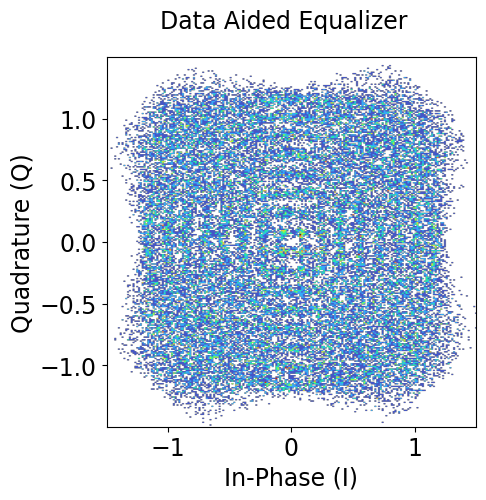

Running frequency offset compensation...


Phase ambiguity resolved: 0.0 deg
yes bps


Estimated frequency offset (MHz): [0.]
Running BPS carrier phase recovery...
Estimated linewidth: 24.544 kHz


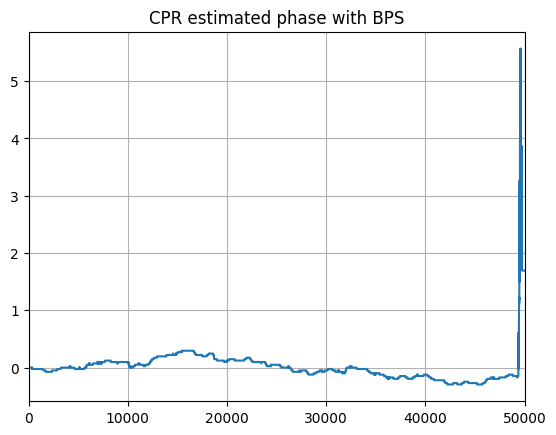

 SER: 9.720e-02
 BER: 1.264e-02
 SNR: 25.079 dB
 EVM: 0.313 %
 Qfactor: 3.497


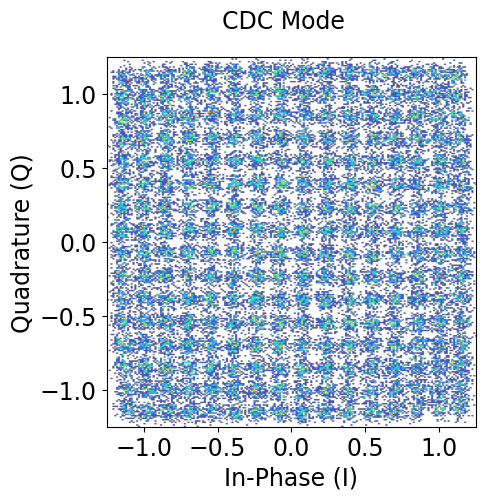

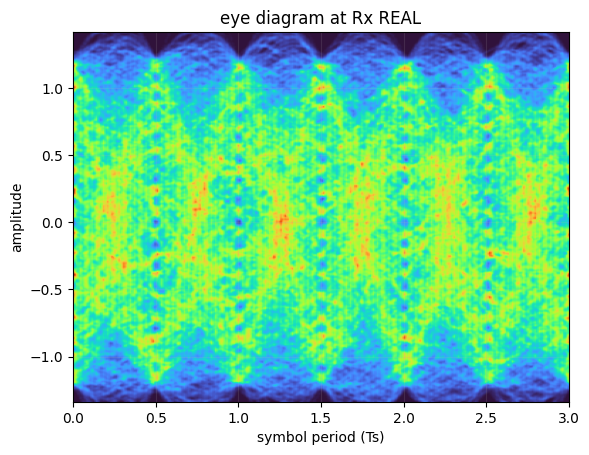

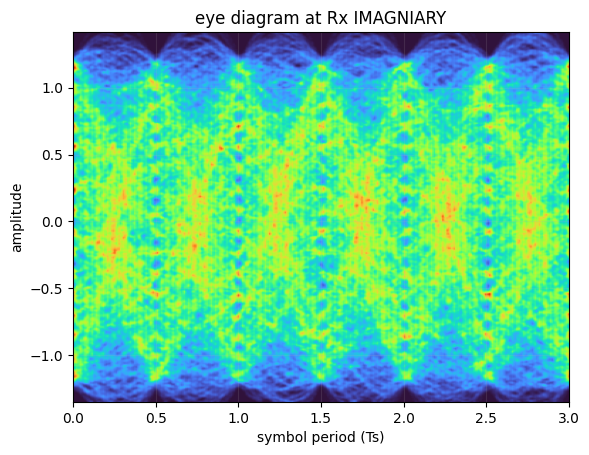

In [14]:
symbTx = symbolSource(paramSymb)


y_CPR_1, d, phaseEst = simulate_optical_system_with_plots(symbTx, len(symbTx), M, PA_enable=True, PA_BO_dB=7, Data_Aided=True,SpS=8, laserLinewidth=10e3, SpSout=SpSout, mzmScale=0.4,useDBP=False)


perf_calc_2(symbTx, y_CPR_1, d, M, paramSymb)


discard = 5000
# plot constellations

fig, ax = pconst(y_CPR_1[discard:-discard])
fig.suptitle("CDC Mode", fontsize=17)
plt.show()

# plotting eye diagrams of sigTx
eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, SpSout, plotlabel='at Rx REAL', ptype='fancy')
eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, SpSout, plotlabel='at Rx IMAGNIARY', ptype='fancy')


In [ ]:
# ── Your existing setup ──────────────────────────────────────────────────────
M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)
symbTx = symbolSource(paramSymb)

# ── Run both simulations at the same launch power ────────────────────────────
y_edc, d_edc, phaseEst_edc = simulate_optical_system_with_plots(
    symbTx, len(symbTx), M,
    PA_enable=True, Data_Aided=True, SpSout=SpSout,
    mzmScale=0.8, useDBP=False, ch_prgsBar=False
)

y_dbp, d_dbp, phaseEst_dbp = simulate_optical_system_with_plots(
    symbTx, len(symbTx), M,
    PA_enable=True, Data_Aided=True, SpSout=SpSout,
    mzmScale=0.8, useDBP=True, ch_prgsBar=False
)

discard = 5000

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Residual Phase Rotation vs Symbol Index
# ════════════════════════════════════════════════════════════════════════════
# Align lengths
N = min(len(y_edc), len(y_dbp), len(d_edc)) - discard

ref      = pnorm(d_edc[discard : discard + N])   # ideal symbols (same for both)
sig_edc  = pnorm(y_edc[discard : discard + N])
sig_dbp  = pnorm(y_dbp[discard : discard + N])

# Residual phase per symbol = angle of (received × conj(ideal))
# If compensation is perfect this should be flat near zero.
# EDC will show structured nonlinear phase bumps; DBP should be flatter.
phase_edc = np.angle(sig_edc * np.conj(ref))
phase_dbp = np.angle(sig_dbp * np.conj(ref))

# Rolling std over a window to show how much phase wanders locally
window    = 500
roll_std_edc = np.array([
    np.std(phase_edc[max(0, i-window): i+window])
    for i in range(0, len(phase_edc), 50)   # subsample for speed
])
roll_std_dbp = np.array([
    np.std(phase_dbp[max(0, i-window): i+window])
    for i in range(0, len(phase_dbp), 50)
])
x_roll = np.arange(len(roll_std_edc)) * 50   # symbol indices

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── Top: EDC raw phase ────────────────────────────────────────────────────
axes[0].plot(phase_edc, alpha=0.4, color='tab:blue', linewidth=0.4)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel("Residual Phase (rad)", fontsize=12)
axes[0].set_title("EDC — Residual Phase per Symbol", fontsize=13, fontweight='bold')
axes[0].set_ylim(-np.pi, np.pi)
axes[0].grid(True, alpha=0.35)

# ── Middle: DBP raw phase ─────────────────────────────────────────────────
axes[1].plot(phase_dbp, alpha=0.4, color='tab:red', linewidth=0.4)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel("Residual Phase (rad)", fontsize=12)
axes[1].set_title("DBP — Residual Phase per Symbol", fontsize=13, fontweight='bold')
axes[1].set_ylim(-np.pi, np.pi)
axes[1].grid(True, alpha=0.35)

# ── Bottom: rolling std comparison ───────────────────────────────────────
# This is the clearest panel — shows WHERE EDC has more phase uncertainty
axes[2].plot(x_roll, roll_std_edc, color='tab:blue', linewidth=2, label='EDC')
axes[2].plot(x_roll, roll_std_dbp, color='tab:red',  linewidth=2, label='DBP')
axes[2].fill_between(x_roll, roll_std_edc, roll_std_dbp,
                     where=(roll_std_edc > roll_std_dbp),
                     alpha=0.15, color='tab:blue',
                     label='EDC worse here')
axes[2].set_ylabel("Local Phase Std (rad)", fontsize=12)
axes[2].set_xlabel("Symbol Index",          fontsize=12)
axes[2].set_title(
    "Rolling Phase Std (window=500 sym) — EDC vs DBP",
    fontsize=13, fontweight='bold'
)
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("residual_phase_edc_vs_dbp.png", dpi=300)
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 — PSD After Compensation
# ════════════════════════════════════════════════════════════════════════════
# y_edc and y_dbp are at 2 Sa/sym after decimation so Fs here = 2*Rs
Fs_plot = 2 * 32e9   # matches SpSout=2, Rs=32e9 — adjust if you changed Rs

fig, ax = plt.subplots(figsize=(12, 5))

ax.psd(y_edc[discard:], Fs=Fs_plot, NFFT=16*1024, sides='twosided',
       label='EDC', color='tab:blue', alpha=0.85, linewidth=1.2)
ax.psd(y_dbp[discard:], Fs=Fs_plot, NFFT=16*1024, sides='twosided',
       label='DBP', color='tab:red',  alpha=0.85, linewidth=1.2)

Rs = 32e9
ax.axvline( Rs/2, color='gray', linestyle=':', linewidth=1.2, label='±Rs/2 boundary')
ax.axvline(-Rs/2, color='gray', linestyle=':',  linewidth=1.2)

ax.set_xlim(-Fs_plot/2, Fs_plot/2)
ax.set_xlabel("Frequency (Hz)", fontsize=13, fontweight='bold')
ax.set_ylabel("PSD (dB/Hz)",    fontsize=13, fontweight='bold')
ax.set_title(
    "PSD After Compensation: EDC vs DBP\n"
    "(DBP should show cleaner spectral shape — less nonlinear broadening)",
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.tick_params(axis='both', labelsize=11)

# Annotate the out-of-band region where nonlinear spectral re-growth shows up
ax.annotate(
    "Nonlinear\nspectral re-growth\n(EDC > DBP here)",
    xy=(Fs_plot * 0.38, ax.get_ylim()[0] + 10),
    fontsize=10, color='tab:blue',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='tab:blue'),
    xytext=(Fs_plot * 0.38, ax.get_ylim()[0] + 30),
)

plt.tight_layout()
plt.savefig("psd_edc_vs_dbp.png", dpi=300)
plt.show()

TX power: 0.001000000000000044


KeyboardInterrupt: 

In [ ]:
# ── Your existing setup ──────────────────────────────────────────────────────
M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)
symbTx = symbolSource(paramSymb)

# ── Run both at HIGH launch power to force nonlinear regime ─────────────────
# Your current run is likely at 0 dBm — push to +6 or +8 dBm
P_high = 8   # dBm — forces Kerr nonlinearity to dominate over ASE

y_edc_high, d_edc_high, _ = simulate_optical_system_with_plots(
    symbTx, len(symbTx), M,
    PA_enable=True, Data_Aided=True, SpSout=SpSout,
    mzmScale=0.8, useDBP=False,
    P_launch_dBm=P_high, ch_prgsBar=False
)

y_dbp_high, d_dbp_high, _ = simulate_optical_system_with_plots(
    symbTx, len(symbTx), M,
    PA_enable=True, Data_Aided=True, SpSout=SpSout,
    mzmScale=0.8, useDBP=True,
    P_launch_dBm=P_high, ch_prgsBar=False
)

discard = 5000
N = min(len(y_edc_high), len(y_dbp_high), len(d_edc_high)) - discard

ref     = pnorm(d_edc_high[discard : discard + N])
sig_edc = pnorm(y_edc_high[discard : discard + N])
sig_dbp = pnorm(y_dbp_high[discard : discard + N])

# ── Correct the static phase offset before computing residual ────────────────
# Without this, the ~1.6 rad DC offset drowns out the nonlinear fluctuations
static_edc = np.angle(np.mean(sig_edc * np.conj(ref)))
static_dbp = np.angle(np.mean(sig_dbp * np.conj(ref)))

sig_edc_corr = sig_edc * np.exp(-1j * static_edc)
sig_dbp_corr = sig_dbp * np.exp(-1j * static_dbp)

phase_edc = np.angle(sig_edc_corr * np.conj(ref))
phase_dbp = np.angle(sig_dbp_corr * np.conj(ref))

# ── Smooth with a moving average to reveal the nonlinear phase trend ─────────
def moving_avg(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode='valid')

phase_edc_smooth = moving_avg(phase_edc, w=200)
phase_dbp_smooth = moving_avg(phase_dbp, w=200)
x_smooth = np.arange(len(phase_edc_smooth))

# ════════════════════════════════════════════════════════════════════════════
# PLOT A — Corrected residual phase comparison (high power)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw phase scatter — now centred near 0
axes[0].plot(phase_edc, alpha=0.3, color='tab:blue', linewidth=0.3, label='EDC raw')
axes[0].plot(x_smooth, phase_edc_smooth, color='navy', linewidth=1.5, label='EDC smoothed')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel("Residual Phase (rad)", fontsize=12)
axes[0].set_title(f"EDC — Residual Phase  [P_launch = +{P_high} dBm]",
                  fontsize=13, fontweight='bold')
axes[0].set_ylim(-np.pi, np.pi)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.35)

axes[1].plot(phase_dbp, alpha=0.3, color='tab:red', linewidth=0.3, label='DBP raw')
axes[1].plot(x_smooth, phase_dbp_smooth, color='darkred', linewidth=1.5, label='DBP smoothed')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel("Residual Phase (rad)", fontsize=12)
axes[1].set_title(f"DBP — Residual Phase  [P_launch = +{P_high} dBm]",
                  fontsize=13, fontweight='bold')
axes[1].set_ylim(-np.pi, np.pi)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.35)

# Phase variance comparison — the key panel
window = 300
roll_var_edc = np.array([np.var(phase_edc[max(0,i-window):i+window])
                          for i in range(0, len(phase_edc), 50)])
roll_var_dbp = np.array([np.var(phase_dbp[max(0,i-window):i+window])
                          for i in range(0, len(phase_dbp), 50)])
x_roll = np.arange(len(roll_var_edc)) * 50

axes[2].plot(x_roll, roll_var_edc, color='tab:blue', linewidth=2, label='EDC')
axes[2].plot(x_roll, roll_var_dbp, color='tab:red',  linewidth=2, label='DBP')
axes[2].fill_between(x_roll, roll_var_edc, roll_var_dbp,
                     where=(roll_var_edc > roll_var_dbp),
                     alpha=0.2, color='tab:blue', label='EDC worse')
axes[2].fill_between(x_roll, roll_var_edc, roll_var_dbp,
                     where=(roll_var_dbp > roll_var_edc),
                     alpha=0.2, color='tab:red', label='DBP worse')
axes[2].set_ylabel("Local Phase Variance (rad²)", fontsize=12)
axes[2].set_xlabel("Symbol Index", fontsize=12)
axes[2].set_title("Rolling Phase Variance — EDC vs DBP  (lower = better)",
                  fontsize=13, fontweight='bold')
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("residual_phase_corrected_high_power.png", dpi=300)
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# PLOT B — Smoothed PSD difference (EDC − DBP) at high power
# This directly shows WHERE in the spectrum DBP helps
# ════════════════════════════════════════════════════════════════════════════
from scipy.signal import welch

Fs_plot = 2 * 32e9
nperseg = 4096

f_edc, Pxx_edc = welch(y_edc_high[discard:], fs=Fs_plot,
                        nperseg=nperseg, return_onesided=False)
f_dbp, Pxx_dbp = welch(y_dbp_high[discard:], fs=Fs_plot,
                        nperseg=nperseg, return_onesided=False)

# Sort by frequency
idx = np.argsort(f_edc)
f      = f_edc[idx]
P_edc  = 10 * np.log10(Pxx_edc[idx])
P_dbp  = 10 * np.log10(Pxx_dbp[idx])
P_diff = P_edc - P_dbp   # positive = EDC has MORE power (nonlinear re-growth)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Absolute PSDs
axes[0].plot(f, P_edc, color='tab:blue', linewidth=1.2, alpha=0.85, label='EDC')
axes[0].plot(f, P_dbp, color='tab:red',  linewidth=1.2, alpha=0.85, label='DBP')
axes[0].axvline( 32e9/2, color='gray', linestyle=':', linewidth=1.2)
axes[0].axvline(-32e9/2, color='gray', linestyle=':', linewidth=1.2,
                label='±Rs/2 boundary')
axes[0].set_ylabel("PSD (dB/Hz)", fontsize=12)
axes[0].set_title(f"PSD After Compensation  [P_launch = +{P_high} dBm]",
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(-Fs_plot/2, Fs_plot/2)

# Difference plot — this is the key panel
axes[1].plot(f, P_diff, color='purple', linewidth=1.5, label='EDC − DBP (dB)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(f, P_diff, 0,
                     where=(P_diff > 0),
                     alpha=0.2, color='tab:blue',
                     label='EDC has more power\n(nonlinear re-growth)')
axes[1].fill_between(f, P_diff, 0,
                     where=(P_diff < 0),
                     alpha=0.2, color='tab:red',
                     label='DBP has more power')
axes[1].axvline( 32e9/2, color='gray', linestyle=':', linewidth=1.2)
axes[1].axvline(-32e9/2, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_ylabel("ΔPSD: EDC − DBP (dB)", fontsize=12)
axes[1].set_xlabel("Frequency (Hz)",        fontsize=12)
axes[1].set_title("Spectral Difference: EDC − DBP  (positive = nonlinear re-growth EDC didn't fix)",
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.4)
axes[1].set_xlim(-Fs_plot/2, Fs_plot/2)

plt.tight_layout()
plt.savefig("psd_difference_high_power.png", dpi=300)
plt.show()

In [ ]:
span_configs = [
    {"n_spans": 1,  "Ltotal": 80},
    {"n_spans": 2,  "Ltotal": 160},
    {"n_spans": 4,  "Ltotal": 320},
    {"n_spans": 8,  "Ltotal": 640},
    {"n_spans": 16, "Ltotal": 1280},
]

P_launch = 4
discard = 5000

ber_edc_spans, ber_dbp_spans = [], []
evm_edc_spans, evm_dbp_spans = [], []
snr_edc_spans, snr_dbp_spans = [], []   # fastBERcalc gives SNR for free
n_spans_list = []

for cfg in span_configs:
    print(f"\n── {cfg['n_spans']} spans ({cfg['Ltotal']} km) ──")
    n_spans_list.append(cfg["n_spans"])

    y_edc, d_edc, _ = simulate_optical_system_with_plots(
        symbTx, len(symbTx), M,
        PA_enable=True, Data_Aided=True, SpSout=SpSout,
        mzmScale=0.8, useDBP=False,
        P_launch_dBm=P_launch,
        ch_Ltotal_km=cfg["Ltotal"],
        ch_Lspan_km=80,
        ch_prgsBar=False,
    )

    y_dbp, d_dbp, _ = simulate_optical_system_with_plots(
        symbTx, len(symbTx), M,
        PA_enable=True, Data_Aided=True, SpSout=SpSout,
        mzmScale=0.8, useDBP=True,
        P_launch_dBm=P_launch,
        ch_Ltotal_km=cfg["Ltotal"],
        ch_Lspan_km=80,
        ch_prgsBar=False,
    )

    # ── fastBERcalc returns (BER, SER, SNR) all as arrays (one per mode) ──
    # Take [0] to get the single-polarisation value
    BER_edc, _, SNR_edc = fastBERcalc(
        y_edc[discard:-discard], d_edc[discard:-discard], M, "qam"
    )
    BER_dbp, _, SNR_dbp = fastBERcalc(
        y_dbp[discard:-discard], d_dbp[discard:-discard], M, "qam"
    )

    ber_edc_spans.append(float(BER_edc[0]))
    ber_dbp_spans.append(float(BER_dbp[0]))
    snr_edc_spans.append(float(SNR_edc[0]))
    snr_dbp_spans.append(float(SNR_dbp[0]))

    # EVM using your existing calcEVM
    evm_edc = calcEVM(
        y_edc[discard:-discard], M, "qam",
        symbTx=d_edc[discard:-discard]
    )
    evm_dbp = calcEVM(
        y_dbp[discard:-discard], M, "qam",
        symbTx=d_dbp[discard:-discard]
    )
    evm_edc_spans.append(100 * np.sqrt(np.mean(evm_edc)))
    evm_dbp_spans.append(100 * np.sqrt(np.mean(evm_dbp)))

    print(f"  BER  EDC: {ber_edc_spans[-1]:.2e}   DBP: {ber_dbp_spans[-1]:.2e}")
    print(f"  SNR  EDC: {snr_edc_spans[-1]:.2f} dB  DBP: {snr_dbp_spans[-1]:.2f} dB")
    print(f"  EVM  EDC: {evm_edc_spans[-1]:.2f}%    DBP: {evm_dbp_spans[-1]:.2f}%")

# ════════════════════════════════════════════════════════════════════════════
# PLOTS — BER, SNR and EVM vs Number of Spans
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── BER ───────────────────────────────────────────────────────────────────
axes[0].semilogy(n_spans_list, ber_edc_spans, 'o-',
                 color='tab:blue', linewidth=2.5, markersize=8, label='EDC')
axes[0].semilogy(n_spans_list, ber_dbp_spans, 's--',
                 color='tab:red',  linewidth=2.5, markersize=8, label='DBP')
axes[0].fill_between(
    n_spans_list, ber_edc_spans, ber_dbp_spans,
    where=[e > d for e, d in zip(ber_edc_spans, ber_dbp_spans)],
    alpha=0.15, color='tab:green', label='DBP gain'
)
axes[0].set_xlabel("Number of Spans (× 80 km)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("BER",                        fontsize=13, fontweight='bold')
axes[0].set_title(f"BER vs Spans\n[P = +{P_launch} dBm, {M}-QAM]",
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(n_spans_list)
axes[0].legend(fontsize=12)
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)

# ── SNR ───────────────────────────────────────────────────────────────────
axes[1].plot(n_spans_list, snr_edc_spans, 'o-',
             color='tab:blue', linewidth=2.5, markersize=8, label='EDC')
axes[1].plot(n_spans_list, snr_dbp_spans, 's--',
             color='tab:red',  linewidth=2.5, markersize=8, label='DBP')
axes[1].fill_between(
    n_spans_list, snr_edc_spans, snr_dbp_spans,
    where=[d > e for e, d in zip(snr_edc_spans, snr_dbp_spans)],
    alpha=0.15, color='tab:green', label='DBP gain'
)
axes[1].set_xlabel("Number of Spans (× 80 km)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("SNR (dB)",                   fontsize=13, fontweight='bold')
axes[1].set_title(f"SNR vs Spans\n[P = +{P_launch} dBm, {M}-QAM]",
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(n_spans_list)
axes[1].legend(fontsize=12)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)

# ── EVM ───────────────────────────────────────────────────────────────────
axes[2].plot(n_spans_list, evm_edc_spans, 'o-',
             color='tab:blue', linewidth=2.5, markersize=8, label='EDC')
axes[2].plot(n_spans_list, evm_dbp_spans, 's--',
             color='tab:red',  linewidth=2.5, markersize=8, label='DBP')
axes[2].fill_between(
    n_spans_list, evm_edc_spans, evm_dbp_spans,
    where=[e > d for e, d in zip(evm_edc_spans, evm_dbp_spans)],
    alpha=0.15, color='tab:green', label='DBP gain'
)
axes[2].set_xlabel("Number of Spans (× 80 km)", fontsize=13, fontweight='bold')
axes[2].set_ylabel("EVM (%)",                    fontsize=13, fontweight='bold')
axes[2].set_title(f"EVM vs Spans\n[P = +{P_launch} dBm, {M}-QAM]",
                  fontsize=13, fontweight='bold')
axes[2].set_xticks(n_spans_list)
axes[2].legend(fontsize=12)
axes[2].grid(True, which='both', linestyle='--', alpha=0.5)

plt.suptitle(
    "EDC vs DBP: Performance Scaling with Number of Spans\n"
    f"(80 km per span, P_launch = +{P_launch} dBm, {M}-QAM)",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("edc_vs_dbp_vs_spans.png", dpi=300)
plt.show()

In [ ]:
# ── Your existing setup ──────────────────────────────────────────────────────
M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)
symbTx = symbolSource(paramSymb)

# ── Your existing single runs (keep these) ───────────────────────────────────
y_CPR_1, d, phaseEst = simulate_optical_system_with_plots(
    symbTx, len(symbTx), M,
    PA_enable=True, Data_Aided=True, SpSout=SpSout,
    mzmScale=0.8, useDBP=False
)
perf_calc(symbTx, y_CPR_1, d, M, paramSymb)

# ── EVM vs Launch Power sweep ────────────────────────────────────────────────
power_range_dBm = np.arange(-4, 8, 2)   # adjust range to your system
discard = 5000

evm_edc_list = []
evm_dbp_list = []

# Shared kwargs — mirrors exactly how you call simulate above
shared_kwargs = dict(
    PA_enable=True,
    Data_Aided=True,
    SpSout=SpSout,
    mzmScale=0.8,
)

for P_dBm in power_range_dBm:
    print(f"\n── P_launch = {P_dBm} dBm ──")

    # EDC run
    y_edc, d_edc, _ = simulate_optical_system_with_plots(
        symbTx, len(symbTx), M,
        P_launch_dBm=P_dBm,
        useDBP=False,
        **shared_kwargs
    )

    # DBP run
    y_dbp, d_dbp, _ = simulate_optical_system_with_plots(
        symbTx, len(symbTx), M,
        P_launch_dBm=P_dBm,
        useDBP=True,
        **shared_kwargs
    )

    # Use your existing calcEVM — slice off transient
    evm_edc = calcEVM(
        y_edc[discard:-discard], M, "qam",
        symbTx=d_edc[discard:-discard]
    )
    evm_dbp = calcEVM(
        y_dbp[discard:-discard], M, "qam",
        symbTx=d_dbp[discard:-discard]
    )

    # calcEVM returns per-dimension array — take mean and convert to %
    evm_edc_list.append(100 * np.sqrt(np.mean(evm_edc)))
    evm_dbp_list.append(100 * np.sqrt(np.mean(evm_dbp)))

    print(f"  EVM EDC: {evm_edc_list[-1]:.2f}%   EVM DBP: {evm_dbp_list[-1]:.2f}%")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(power_range_dBm, evm_edc_list, 'o-',  color='tab:blue',
        linewidth=2.5, markersize=7, label='EDC')
ax.plot(power_range_dBm, evm_dbp_list, 's--', color='tab:red',
        linewidth=2.5, markersize=7, label='DBP')

ax.set_xlabel("Launch Power (dBm)",  fontsize=14, fontweight='bold')
ax.set_ylabel("EVM (%)",             fontsize=14, fontweight='bold')
ax.set_title(
    f"EVM vs Launch Power: EDC vs DBP  [{M}-QAM, 80 km span]",
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=13)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("evm_vs_launch_power_edc_vs_dbp.png", dpi=300)
plt.show()

# No DPD

In [ ]:
M = 64
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)


In [ ]:
symbTx = symbolSource(paramSymb)


y_CPR_1, d, phaseEst = simulate_optical_system_with_plots(symbTx, len(symbTx), M, PA_enable=True, Data_Aided=True, laserLinewidth=10e3, SpSout=SpSout, mzmScale=0.8,useDBP=False)


perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


discard = 5000
# plot constellations

fig, ax = pconst(y_CPR_1[discard:-discard])
fig.suptitle("Data Aided Equalizer and CPR", fontsize=17)
plt.show()

# plotting eye diagrams of sigTx
eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, SpSout, plotlabel='at Rx REAL', ptype='fancy')
eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, SpSout, plotlabel='at Rx IMAGNIARY', ptype='fancy')


In [ ]:
results = []

# modulation orders to test
mod_orders = [256]

# DA and CPR modes
modes_DataAided = [True, False]
modes_CPR = [ "bps","ddpll"]

for M_test in mod_orders:
    M = M_test
    paramSymb = intialise_paramSymb(M, nBits) # need to update it everytime M changes
    for da in modes_DataAided:
        for cpr_mode in modes_CPR:
            print("\n===================================================")
            print(f" Running:  M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}")
            print("===================================================\n")
        
            # fresh symbol stream each run
            symbTx = symbolSource(paramSymb)
            
            # run sys
            y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, 
                                                            Data_Aided=da, 
                                                            SpSout=SpSout,
                                                            CPR_Mode=cpr_mode)

            discard = 5000

            # optional: plot constellations
            pconst(y_CPR_1[discard:-discard])

            # plotting eye diagrams
            eyediagram(y_CPR_1.real[discard:-discard],
                        y_CPR_1.real.size-2*discard,
                        SpSout,
                        plotlabel=f'signal at Rx REAL, M={M}', ptype='fancy')
            eyediagram(y_CPR_1.imag[discard:-discard],
                        y_CPR_1.imag.size-2*discard,
                        SpSout,
                        plotlabel=f'signal at Rx IMAGINARY, M={M}', ptype='fancy')


            # performance
            BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


            results.append({
                "Modulation": M,
                "Data_Aided": da,
                "CPR": cpr_mode,
                "BER": BER,
                "SER": SER,
                "SNR": SNR,
                "EVM": EVM,
                "Qfactor": Q
             })


# Results at mzm 0.8

In [ ]:
print("\n==================== SUMMARY TABLE ====================\n")
for r in results:
    print(f"DA={r['Data_Aided']}, CPR={r['CPR']}, M={r['Modulation']}: "
           f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
           f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Group BER values by (DA, CPR)
groups = defaultdict(lambda: {"M": [], "BER": []})

for r in results:
    key = f"DA={r['Data_Aided']}, CPR={r['CPR']}"
    groups[key]["M"].append(r["Modulation"])
    groups[key]["BER"].append(r["BER"])

# Plot
plt.figure(figsize=(8,6))

for label, data in groups.items():
    plt.semilogy(data["M"], data["BER"], marker='o', linewidth=2, label=label)

# Add x-axis markers for M=16, 64, 256
plt.xticks([16, 64, 256], ["16", "64", "256"])

plt.grid(True, which='both', linestyle='--')
plt.xlabel("Modulation Order (M)")
plt.ylabel("BER")
plt.title("BER vs Modulation Order")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# ---------------------------------------------------------
# 1. Convert results → DataFrame and save to CSV
# ---------------------------------------------------------
df = pd.DataFrame(results)

csv_filename = "results_BER_vs_Modulation.csv"
df.to_csv(csv_filename, index=False)

print(f"Saved results to: {csv_filename}")

# ---------------------------------------------------------
# 2. Group BER values by (DA, CPR)
# ---------------------------------------------------------
groups = defaultdict(lambda: {"M": [], "BER": []})

for r in results:
    key = f"DA={r['Data_Aided']}, CPR={r['CPR']}"
    groups[key]["M"].append(r["Modulation"])
    groups[key]["BER"].append(r["BER"])

# ---------------------------------------------------------
# 3. Plot BER vs Modulation Order
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

for label, data in groups.items():
    plt.semilogy(
        data["M"],
        data["BER"],
        marker='o',
        linewidth=2,
        label=label
    )

# X-axis ticks for M = 16, 64, 256
plt.xticks([16, 64, 256], ["16", "64", "256"])

plt.grid(True, which='both', linestyle='--')
plt.xlabel("Modulation Order (M)")
plt.ylabel("BER")
plt.title("BER vs Modulation Order")
plt.legend()
plt.tight_layout()
plt.show()